# Predicting NYC Restaurant Shutdowns with Survival Analysis



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import pairwise_logrank_test

warnings.filterwarnings("ignore")  # hide pandas FutureWarning + lifelines observed=False spam

df = pd.read_csv("restaurant_survival.csv")

# collapse ~80 cuisines to the 12 most common + "Other" so each category has enough events
top = df["CUISINE"].value_counts().head(12).index
df["cuisine_bucket"] = np.where(df["CUISINE"].isin(top), df["CUISINE"], "Other")

## Kaplan–Meier curves

How long do restaurants survive, and do the curves differ by borough and cuisine?

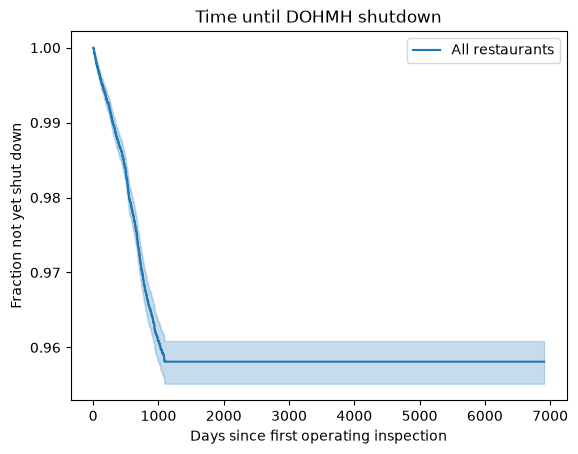

In [ ]:
# unconditional curve
kmf = KaplanMeierFitter()
kmf.fit(df["duration_days"], df["event"], label="All restaurants")
kmf.plot_survival_function()
plt.title("Time until DOHMH shutdown")
plt.xlabel("Days since first operating inspection")
plt.ylabel("Fraction not yet shut down")
plt.show()

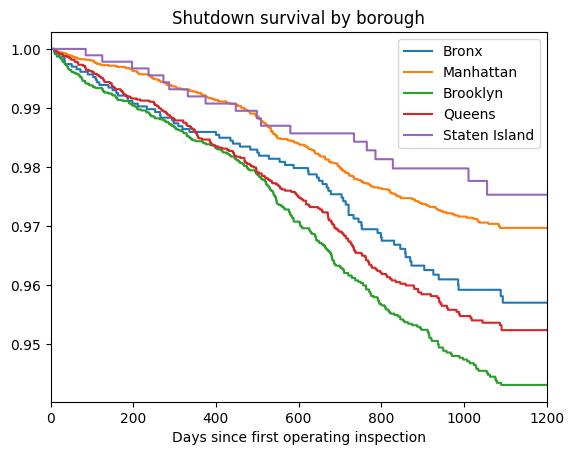

In [6]:
# split by borough
ax = plt.subplot()
for boro in df["BORO"].dropna().unique():
    m = df["BORO"] == boro
    KaplanMeierFitter().fit(df.loc[m, "duration_days"], df.loc[m, "event"], label=boro
        ).plot_survival_function(ax=ax, ci_show=False)
plt.title("Shutdown survival by borough")
plt.xlabel("Days since first operating inspection")
plt.xlim(0, 1200)
plt.show()


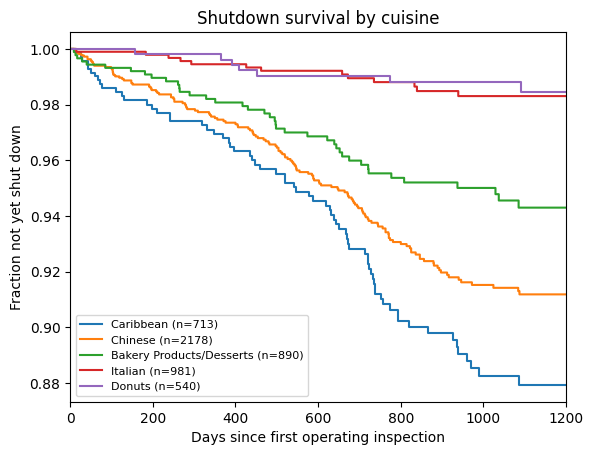

In [7]:
# a few cuisines spanning high- to low-hazard
kmf = KaplanMeierFitter()
ax = plt.subplot()
show = ["Caribbean", "Chinese", "Bakery Products/Desserts", "Italian", "Donuts"]

for c in show:
    m = df["cuisine_bucket"] == c
    if m.sum() > 0:
        kmf.fit(df.loc[m, "duration_days"], df.loc[m, "event"], label=f"{c} (n={m.sum()})")
        kmf.plot_survival_function(ax=ax, ci_show=False)

plt.title("Shutdown survival by cuisine")
plt.xlabel("Days since first operating inspection")
plt.ylabel("Fraction not yet shut down")
plt.xlim(0, 1200)
plt.legend(fontsize=8)
plt.show()

## Cox proportional-hazards model

In [8]:
# one row per restaurant: baseline score/violations + borough + cuisine, one-hot encoded
cox_df = df[["duration_days","event","init_score","init_health_viol","init_admin_viol","BORO","cuisine_bucket"]].dropna().copy()
cox_df = pd.get_dummies(cox_df, columns=["BORO","cuisine_bucket"], drop_first=True).astype(float)

cph = CoxPHFitter()
cph.fit(cox_df, "duration_days", "event")
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 26534 total observations, 25689 right-censored observations>
             duration col = 'duration_days'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 26534
number of events observed = 845
   partial log-likelihood = -8037.64
         time fit was run = 2026-07-10 02:51:04 UTC

---
                                         coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                                
init_score                               0.02      1.02      0.00            0.01            0.03                1.01                1.03
init_health_viol                         0.16      1.17      0.02            0.11            0.20                1.11                1.23
init_admin_viol                          0.08      1.09      0.07           -0.05            0.21                0.96                1.23
BORO_Brooklyn                            0.28      1.33      0.13            0.03            0.54                1.03                1.71
BORO_Manhattan                          -0.15      0.86      0.13           -0.42            0.11                0.66                1.12
BORO_Queens                              0.01      1.01      0.13           -0.25            0.27                0.78                1.31
BORO_Staten Island                      -0.42      0.66      0.26           -0.93            0.10                0.39                1.10
cuisine_bucket_Bakery Products/Desserts  1.17      3.21      0.20            0.77            1.57                2.15                4.79
cuisine_bucket_Caribbean                 1.65      5.22      0.18            1.30            2.00                3.67                7.41
cuisine_bucket_Chicken                   0.99      2.68      0.23            0.53            1.44                1.70                4.23
cuisine_bucket_Chinese                   1.40      4.04      0.15            1.09            1.70                2.98                5.47
cuisine_bucket_Coffee/Tea                0.59      1.80      0.19            0.20            0.97                1.23                2.63
cuisine_bucket_Donuts                    0.16      1.17      0.40           -0.62            0.94                0.54                2.57
cuisine_bucket_Italian                   0.00      1.00      0.31           -0.59            0.60                0.55                1.83
cuisine_bucket_Japanese                  0.68      1.96      0.23            0.22            1.13                1.25                3.09
cuisine_bucket_Latin American            0.93      2.54      0.20            0.54            1.32                1.72                3.76
cuisine_bucket_Mexican                   0.60      1.82      0.22            0.17            1.03                1.19                2.80
cuisine_bucket_Other                     0.83      2.30      0.14            0.55            1.11                1.74                3.03
cuisine_bucket_Pizza                     0.58      1.79      0.20            0.19            0.98                1.20                2.67

                                         cmp to     z      p  -log2(p)
covariate                                                             
init_score                                 0.00  5.78 <0.005     27.00
init_health_viol                           0.00  6.44 <0.005     32.94
init_admin_viol                            0.00  1.26   0.21      2.28
BORO_Brooklyn                              0.00  2.20   0.03      5.16
BORO_Manhattan                             0.00 -1.13   0.26      1.96
BORO_Queens                                0.00  0.06   0.95      0.07
BORO_Staten Island                         0.00 -1.59   0.11      3.15
cuisine_bucket_Bakery Products/Desserts    0.00  5.71 <0.005     26.38
cuisine_bucket_Car

## 3. Proportional-hazards assumption check

The Cox model assumes each covariate's effect on the hazard is constant over time.


   Bootstrapping lowess lines. May take a moment...

The ``p_value_threshold`` is set at 0.01. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'init_score' failed the non-proportional test: p-value is <5e-05.

   Advice 1: the functional form of the variable 'init_score' might be incorrect. That is, there may
be non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'init_score' using pd.cut, and then specify it in
`strata=['init_score', ...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Bin-variable-and-stratify-on-it
[C]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumpti

[[<Axes: xlabel='rank-transformed time\n(p=0.0000)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0000)'>]]

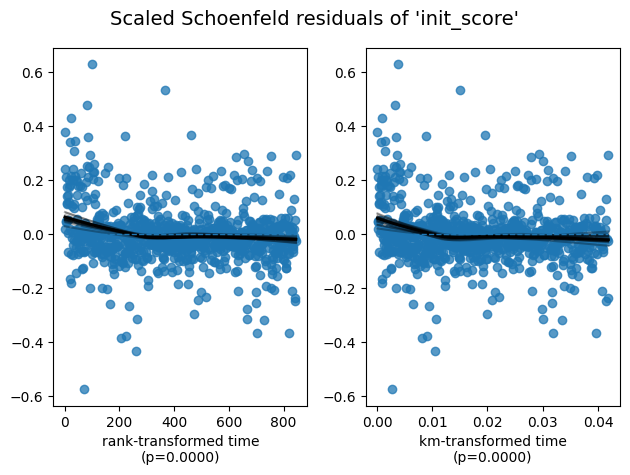

In [9]:
cph.check_assumptions(cox_df, columns=["init_score"], show_plots=True)

The Schoenfeld residuals for `init_score` trend with time which is a proportional-hazards violation (p ≈ 3e-7).

**Fix:** `init_score` maps directly onto NYC's A/B/C letter grades, so bin it at those thresholds and **stratify** on the bin instead of fitting it as one linear coefficient. Stratifying gives each grade its own baseline hazard rather than assuming a constant multiplier over time.

In [10]:
# NYC letter grades: A = 0-13, B = 14-27, C = 28+
score_bins, score_labels = [-1, 13, 27, np.inf], ["A", "B", "C"]
cox_df["score_grade"] = pd.cut(cox_df["init_score"], bins=score_bins, labels=score_labels)
cox_df = cox_df.drop(columns="init_score")

cph = CoxPHFitter()
cph.fit(cox_df, "duration_days", "event", strata="score_grade")
cph.print_summary()
cph.check_assumptions(cox_df, show_plots=False, advice=False)

<lifelines.CoxPHFitter: fitted with 26534 total observations, 25689 right-censored observations>
             duration col = 'duration_days'
                event col = 'event'
                   strata = score_grade
      baseline estimation = breslow
   number of observations = 26534
number of events observed = 845
   partial log-likelihood = -7150.49
         time fit was run = 2026-07-10 02:51:58 UTC

---
                                         coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                                
init_health_viol                         0.16      1.17      0.02            0.12            0.20                1.12                1.22
init_admin_viol                          0.08      1.09      0.07           -0.05            0.21                0.95                1.24
BORO_Brooklyn                            0.28      1.32      0.13            0.02            0.53                1.02                1.70
BORO_Manhattan                          -0.15      0.86      0.13           -0.41            0.11                0.66                1.12
BORO_Queens                              0.00      1.00      0.13           -0.26            0.26                0.77                1.30
BORO_Staten Island                      -0.41      0.67      0.26           -0.92            0.11                0.40                1.12
cuisine_bucket_Bakery Products/Desserts  1.16      3.18      0.20            0.76            1.56                2.13                4.75
cuisine_bucket_Caribbean                 1.64      5.16      0.18            1.29            1.99                3.63                7.34
cuisine_bucket_Chicken                   1.00      2.71      0.23            0.54            1.45                1.71                4.27
cuisine_bucket_Chinese                   1.37      3.94      0.15            1.07            1.68                2.91                5.34
cuisine_bucket_Coffee/Tea                0.59      1.81      0.19            0.21            0.97                1.23                2.64
cuisine_bucket_Donuts                    0.18      1.20      0.40           -0.60            0.97                0.55                2.63
cuisine_bucket_Italian                  -0.00      1.00      0.31           -0.60            0.59                0.55                1.81
cuisine_bucket_Japanese                  0.67      1.96      0.23            0.22            1.13                1.24                3.08
cuisine_bucket_Latin American            0.92      2.51      0.20            0.53            1.31                1.70                3.71
cuisine_bucket_Mexican                   0.62      1.85      0.22            0.19            1.05                1.21                2.85
cuisine_bucket_Other                     0.82      2.26      0.14            0.54            1.09                1.71                2.98
cuisine_bucket_Pizza                     0.59      1.81      0.20            0.20            0.99                1.22                2.70

                                         cmp to     z      p  -log2(p)
covariate                                                             
init_health_viol                           0.00  7.37 <0.005     42.40
init_admin_viol                            0.00  1.24   0.22      2.21
BORO_Brooklyn                              0.00  2.15   0.03      4.99
BORO_Manhattan                             0.00 -1.13   0.26      1.94
BORO_Queens                                0.00  0.00   1.00      0.01
BORO_Staten Island                         0.00 -1.54   0.12      3.03
cuisine_bucket_Bakery Products/Desserts    0.00  5.67 <0.005     26.07
cuisine_bucket_Caribbean                   0.00  9.16 <0.005     64.07
cuisine_bucket_Chicken                     0.00  4.27 <0.005     15.64
cuisine_bucket_Chinese                     0.



1. Variable 'init_health_viol' failed the non-proportional test: p-value is 0.0032.


2. Variable 'cuisine_bucket_Caribbean' failed the non-proportional test: p-value is 0.0094.



[]

Stratifying resolves `init_score`. The re-check now surfaces two **mild** flags — `init_health_viol` (p = 0.003) and `Caribbean` (p = 0.009) — both just under the 0.01 threshold and an order of magnitude weaker than `init_score`'s violation (3e-7). As lifelines warns above, at this sample size the test flags even trivial deviations. Stratifying these out too would trade away the interpretable hazard ratios that are the point of the model (notably the headline Caribbean cuisine effect), so we judge them acceptable and keep the current model.

## Cox VS. Random Survival Forest



In [12]:
from sksurv.ensemble import RandomSurvivalForest
from sksurv.util import Surv
from sklearn.model_selection import train_test_split

In [13]:
feat = df[["init_score","init_health_viol","init_admin_viol","BORO","cuisine_bucket"]].copy()
feat = pd.get_dummies(feat, columns=["BORO","cuisine_bucket"], drop_first=True).astype(float)

mask = feat.notna().all(axis=1) & df["init_score"].notna()
X = feat[mask].values
y = Surv.from_arrays(event=df.loc[mask,"event"].astype(bool), time=df.loc[mask,"duration_days"])

In [14]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=42)

rsf = RandomSurvivalForest(n_estimators=200, min_samples_leaf=30,
                           n_jobs=-1, random_state=42)
rsf.fit(X_tr, y_tr)

RandomSurvivalForest(min_samples_leaf=30, n_estimators=200, n_jobs=-1,
                     random_state=42)

In [ ]:
from lifelines.utils import concordance_index

# fair benchmark: same features as the RSF (raw score, no binning), same split + seed,
# so Cox and RSF are scored on the identical held-out test rows
data = df[["duration_days","event","init_score","init_health_viol",
           "init_admin_viol","BORO","cuisine_bucket"]].dropna()
data = pd.get_dummies(data, columns=["BORO","cuisine_bucket"], drop_first=True).astype(float)
tr, te = train_test_split(data, test_size=0.25, random_state=42)

# Cox trained ONLY on the training split (never sees the test set)
cox_bench = CoxPHFitter(penalizer=0.01).fit(tr, "duration_days", "event")
cox_c = concordance_index(te["duration_days"], -cox_bench.predict_partial_hazard(te), te["event"])

print(f"Cox concordance (test): {cox_c:.3f}")
print(f"RSF concordance (test): {rsf.score(X_te, y_te):.3f}")

Cox concordance (test): 0.737


RSF concordance (test): 0.738


## 5. Calibration

Check calibration at a 2-year (730-day) horizon.

ICI =  0.002846314977141837
E50 =  0.0016934449397306706


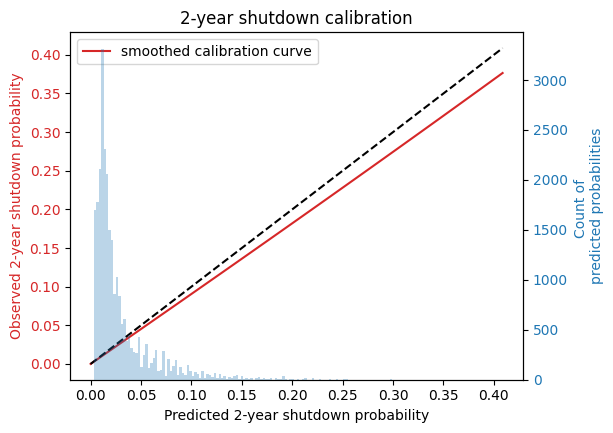

In [16]:
from lifelines.calibration import survival_probability_calibration

survival_probability_calibration(cph, cox_df, t0=730)

fig = plt.gcf()
curve_ax = next((a for a in fig.axes if "mortality" in (a.get_xlabel() + a.get_ylabel()).lower()),
                fig.axes[0])
curve_ax.set_title("2-year shutdown calibration")
curve_ax.set_xlabel("Predicted 2-year shutdown probability")
curve_ax.set_ylabel("Observed 2-year shutdown probability")
plt.show()